In [24]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from scipy.optimize import fmin_tnc
from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.svm import SVC, NuSVC, LinearSVC, OneClassSVM, SVR, NuSVR, LinearSVR
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

In [3]:
data = pd.read_csv('Titanic-Dataset.csv', sep=",")

In [5]:
data.shape

(891, 12)

In [7]:
# проверим есть ли пропущенные значения
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [18]:
# Копируем данные
data_processed = data.copy()

In [20]:
#удаление сталбца Cabin - смысла в нем, потому что он нам ничего сказать не может 
data_processed = data_processed.drop('Cabin', axis=1)
data_processed.shape

(891, 11)

In [26]:
# кодируем категориальные признаки Sex и Embarked
data_processed['Sex'] = LabelEncoder().fit_transform(data_processed['Sex']) # male->0, female->1
data_processed['Embarked'] = LabelEncoder().fit_transform(data_processed['Embarked']) # S->0, C->1, Q->2
data_processed.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

In [28]:
# заполняем пропуски в Age медианой
data_processed['Age'] = data_processed['Age'].fillna(data_processed['Age'].median())
data_processed.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [30]:
# формируем X и y
y = data_processed['Survived']
X = data_processed.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% данных в тест, 80% в обучение
    random_state=42,      # фиксация для воспроизводимости
    stratify=y            # сохраняет исходное соотношение классов (выжил/не выжил)
)

In [34]:
# Проверка размеров
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (712, 7), y_train: (712,)
X_test:  (179, 7), y_test:  (179,)


In [38]:
from operator import itemgetter
import matplotlib.ticker as ticker
import math

In [40]:
from enum import Enum
class PredictionType(Enum):
    CLASSIFICATION = 1
    REGRESSION = 2

In [44]:
class SimpleKNN:
    
    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        """Метод обучения — запоминает обучающую выборку"""
        self._X_train = X_train.reset_index(drop=True)  # сброс индекса
        self._y_train = y_train.reset_index(drop=True)
          
    def eucl_dist(self, p: np.ndarray, q: np.ndarray) -> float:
        """Евклидово расстояние"""
        return math.sqrt(sum([(pi - qi) ** 2 for pi, qi in zip(p, q)]))
            
    def predict_for_single_object(self, K: int, 
                prediction_type: PredictionType, 
                X_o: np.ndarray, 
                verbose=False) -> np.ndarray:
        """Предсказание для одного объекта"""
        neighbors_list = []
        
        for i in range(self._X_train.shape[0]):
            # ✅ ИСПРАВЛЕНО: используем .values для любых признаков
            data_train_current_x = self._X_train.iloc[i].values.astype(float)
            data_train_current_y = self._y_train.iloc[i]
            dist = self.eucl_dist(X_o, data_train_current_x)
            neighbors_list.append((data_train_current_y, dist, data_train_current_x))
        
        neighbors_list_sorted = sorted(neighbors_list, key=itemgetter(1))
        
        K_neighbors_list_sorted = neighbors_list_sorted[:K]
        
        if prediction_type == PredictionType.REGRESSION:
            arr = np.array([x for x, _, _ in K_neighbors_list_sorted])
            return np.mean(arr)          
        elif prediction_type == PredictionType.CLASSIFICATION:
            k_y_list = [y for y, _, _ in K_neighbors_list_sorted]
            k_y_list_grouped_temp = np.unique(k_y_list, return_counts=True)
            k_y_list_grouped = [[key, cnt] for key, cnt in zip(k_y_list_grouped_temp[0], k_y_list_grouped_temp[1])]
            k_y_list_grouped_sorted = sorted(k_y_list_grouped, key=itemgetter(1), reverse=True)
            return k_y_list_grouped_sorted[0][0]
        else:
            raise Exception('Неизвестный тип предсказания')
                   
    def predict(self, K: int, prediction_type: PredictionType, 
                X_test: pd.DataFrame, verbose=False) -> np.ndarray:
        """Предсказание для всей тестовой выборки"""
        test_data_temp = [X_test.iloc[i].values.astype(float) for i in range(X_test.shape[0])]
        return [self.predict_for_single_object(K=K, prediction_type=prediction_type, 
                X_o=i, verbose=verbose) for i in test_data_temp]

In [46]:
data_train = pd.concat([X_train, y_train], axis=1)
data_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
692,3,1,28.0,0,0,56.4958,2,1
481,2,1,28.0,0,0,0.0000,2,0
527,1,1,28.0,0,0,221.7792,2,0
855,3,0,18.0,0,1,9.3500,2,1
801,2,0,31.0,1,1,26.2500,2,1
...,...,...,...,...,...,...,...,...
359,3,0,28.0,0,0,7.8792,1,1
258,1,0,35.0,0,0,512.3292,0,1
736,3,0,48.0,1,3,34.3750,2,0
462,1,1,47.0,0,0,38.5000,2,0


In [48]:
def fare_to_class(fare: float) -> str:
    if fare < 10:
        result = 'A'  # Третий класс, низкая цена
    elif fare < 30:
        result = 'B'  # Второй класс, средняя цена
    elif fare < 100:
        result = 'C'  # Первый/второй класс, высокая цена
    else:
        result = 'D'  # Первый класс, премиум
    return result

In [52]:
# формирование второго целевого признака для классификации
data_train['Fare_clas'] = \
data_train.apply(lambda row: fare_to_class(row['Fare']),axis=1)
data_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,Fare_clas
692,3,1,28.0,0,0,56.4958,2,1,C
481,2,1,28.0,0,0,0.0000,2,0,A
527,1,1,28.0,0,0,221.7792,2,0,D
855,3,0,18.0,0,1,9.3500,2,1,A
801,2,0,31.0,1,1,26.2500,2,1,B
...,...,...,...,...,...,...,...,...,...
359,3,0,28.0,0,0,7.8792,1,1,A
258,1,0,35.0,0,0,512.3292,0,1,D
736,3,0,48.0,1,3,34.3750,2,0,C
462,1,1,47.0,0,0,38.5000,2,0,C


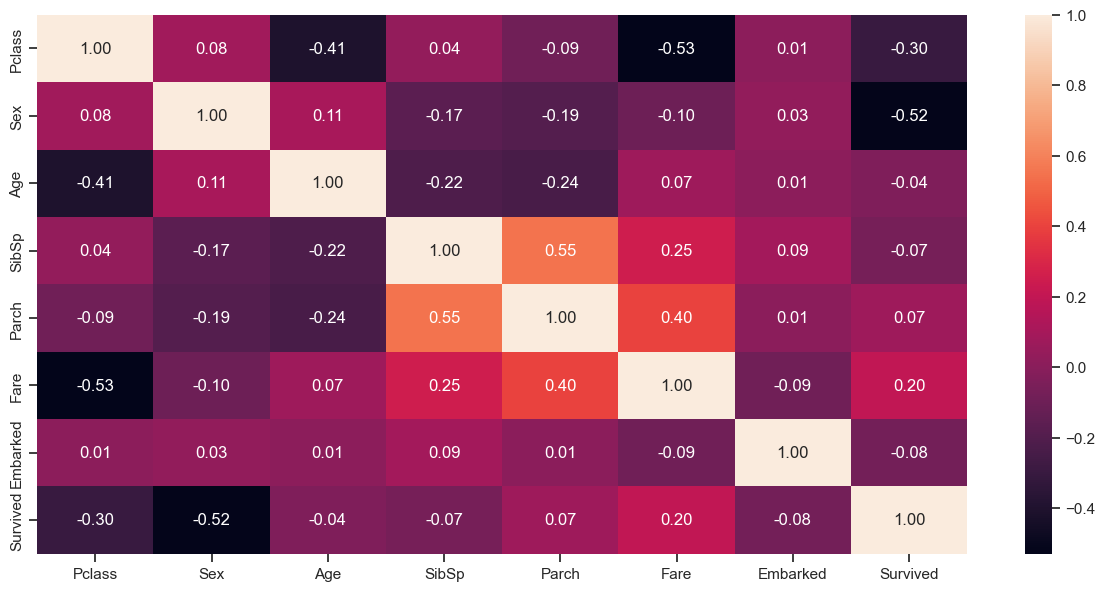

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
data_test = pd.concat([X_test, y_test], axis=1)

# Выбираем только числовые колонки
numeric_columns = data_test.select_dtypes(include=['int64', 'float64']).columns
data_numeric_test = data_test[numeric_columns].copy()

# Выбираем только числовые колонки
numeric_columns = data_train.select_dtypes(include=['int64', 'float64']).columns
data_numeric_train = data_train[numeric_columns].copy()

# Построим корреляционную матрицу
fig, ax = plt.subplots(figsize=(15,7))
sns.heatmap(data_numeric_test.corr(method='pearson'), ax=ax, annot=True, fmt='.2f')
plt.show()

<Axes: xlabel='Age', ylabel='Fare'>

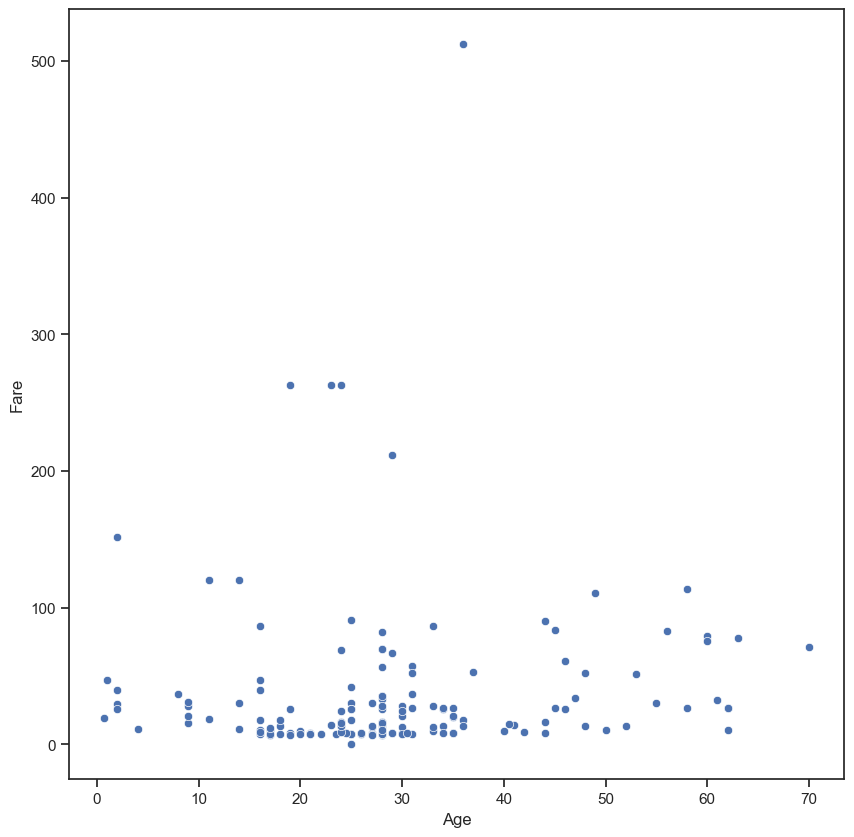

In [58]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='Age', y='Fare', data=data_numeric_test)

In [60]:
#Аналитическое восстановление зависимости

# Аналитическое вычисление коэффициентов регрессии
def analytic_regr_coef(x_array : np.ndarray, 
                       y_array : np.ndarray) -> Tuple[float, float]:
    x_mean = np.mean(x_array)
    y_mean = np.mean(y_array)
    var1 = np.sum([(x-x_mean)**2 for x in x_array])
    cov1 = np.sum([(x-x_mean)*(y-y_mean) for x, y in zip(x_array, y_array)])
    b1 = cov1 / var1
    b0 = y_mean - b1*x_mean
    return b0, b1

In [62]:
x_array = data_numeric_test['Age'].values
y_array = data_numeric_test['Fare'].values

In [64]:
b0, b1 = analytic_regr_coef(x_array, y_array)
b0, b1
#Аналитически вычисленные коэффициенты b0, b1 
#будут использоваться в дальнейшем для сравнения с другими моделями.

(25.277532667062726, 0.2918680330898659)

In [66]:
# Вычисление значений y на основе x для регрессии
def y_regr(x_array : np.ndarray, b0: float, b1: float) -> np.ndarray:
    res = [b1*x+b0 for x in x_array]
    return res

In [68]:
y_array_regr = y_regr(x_array, b0, b1)

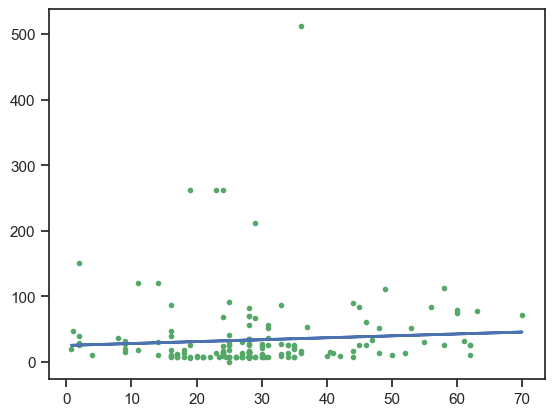

In [70]:
plt.plot(x_array, y_array, 'g.')
plt.plot(x_array, y_array_regr, 'b', linewidth=2.0)
plt.show()

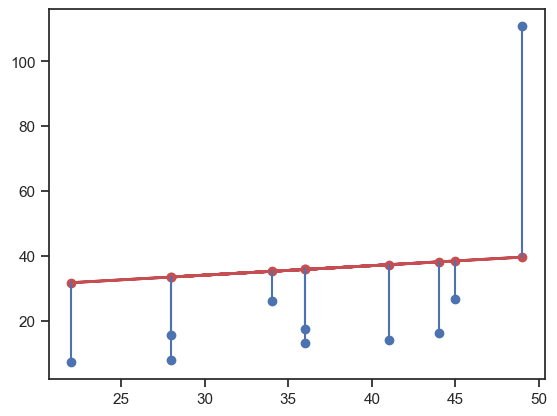

In [72]:
#Восстановление зависимости с использованием численных методов

#МНК

# Синими отрезками показаны ошибки между 
# истинными и предсказанными значениями
K_mnk=10

plt.plot(x_array[1:K_mnk+1], y_array[1:K_mnk+1], 'bo')
plt.plot(x_array[1:K_mnk+1], y_array_regr[1:K_mnk+1], '-ro', linewidth=2.0)

for i in range(len(x_array[1:K_mnk+1])):
    x1 = x_array[1:K_mnk+1][i]
    y1 = y_array[1:K_mnk+1][i]
    y2 = y_array_regr[1:K_mnk+1][i]
    plt.plot([x1,x1],[y1,y2],'b-')

plt.show()

In [74]:
# Простейшая реализация градиентного спуска
def gradient_descent(x_array : np.ndarray,
                     y_array : np.ndarray,
                     b0_0 : float,
                     b1_0 : float,
                     epochs : int,
                     learning_rate : float = 0.001
                    ) -> Tuple[float, float]:
    # Значения для коэффициентов по умолчанию
    b0, b1 = b0_0, b1_0
    k = float(len(x_array))
    for i in range(epochs): 
        # Вычисление новых предсказанных значений
        # используется векторизованное умножение и сложение для вектора и константы
        y_pred = b1 * x_array + b0
        # Расчет градиентов
        # np.multiply - поэлементное умножение векторов
        dL_db1 = (-2/k) * np.sum(np.multiply(x_array, (y_array - y_pred)))
        dL_db0 = (-2/k) * np.sum(y_array - y_pred)
        # Изменение значений коэффициентов:
        b1 = b1 - learning_rate * dL_db1
        b0 = b0 - learning_rate * dL_db0
    # Результирующие значения
    y_pred = b1 * x_array + b0
    return b0, b1, y_pred


In [76]:
def show_gradient_descent(epochs, b0_0, b1_0):
    grad_b0, grad_b1, grad_y_pred = gradient_descent(x_array, y_array, b0_0, b1_0, epochs)
    print('b0 = {} - (теоретический), {} - (градиентный спуск)'.format(b0, grad_b0))
    print('b1 = {} - (теоретический), {} - (градиентный спуск)'.format(b1, grad_b1))
    print('MSE = {}'.format(mean_squared_error(y_array_regr, grad_y_pred)))
    plt.plot(x_array, y_array, 'g.')
    plt.plot(x_array, y_array_regr, 'b', linewidth=2.0)
    plt.plot(x_array, grad_y_pred, 'r', linewidth=2.0)
    plt.show()

b0 = 25.277532667062726 - (теоретический), 0.07895007816232974 - (градиентный спуск)
b1 = 0.2918680330898659 - (теоретический), -0.17559101444886016 - (градиентный спуск)
MSE = 1537.5426781215947


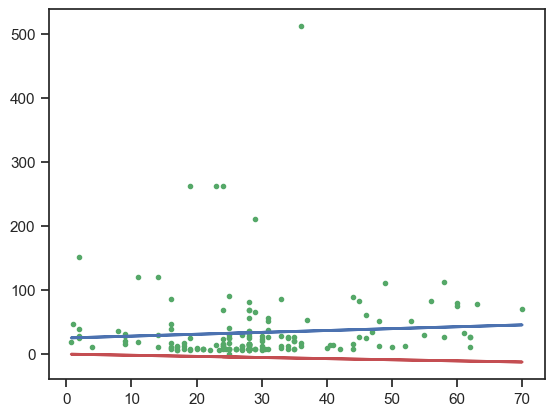

In [78]:
# Примеры использования градиентного спуска
show_gradient_descent(10, 0, 0)

b0 = 25.277532667062726 - (теоретический), -193984.83480402542 - (градиентный спуск)
b1 = 0.2918680330898659 - (теоретический), -6742454.429120682 - (градиентный спуск)
MSE = 4.585844994031998e+16


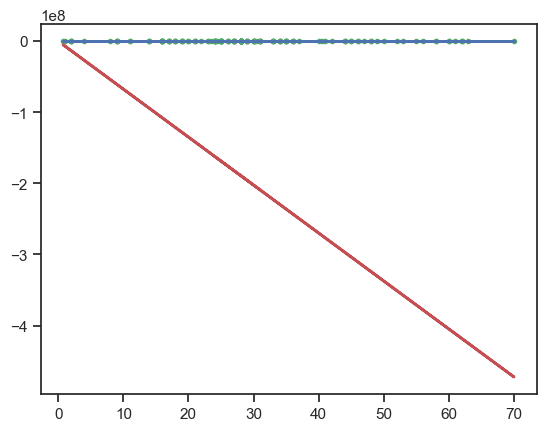

In [80]:
show_gradient_descent(1000, 0, 0)

b0 = 25.277532667062726 - (теоретический), -29.800700711196193 - (градиентный спуск)
b1 = 0.2918680330898659 - (теоретический), 5.5244730230751316 - (градиентный спуск)
MSE = 13908.808053915649


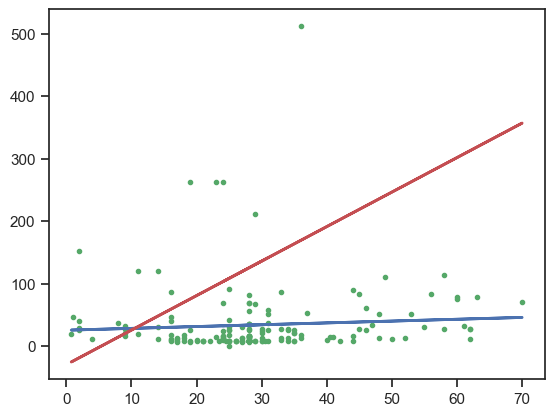

In [86]:
# Сходимость алгоритма может сильно зависеть от начальных значений
show_gradient_descent(10, -30, 5)

b0 = 25.277532667062726 - (теоретический), 3929371584830.1826 - (градиентный спуск)
b1 = 0.2918680330898659 - (теоретический), 136570631828073.03 - (градиентный спуск)
MSE = 1.881472452475683e+31


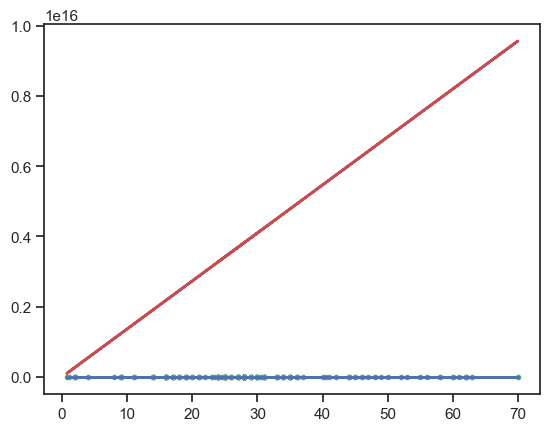

In [88]:
show_gradient_descent(2000, -30, 5)

In [90]:
#Использование класса LinearRegression библиотеки scikit-learn.
# Обучим линейную регрессию и сравним коэффициенты с рассчитанными ранее
reg1 = LinearRegression().fit(x_array.reshape(-1, 1), y_array.reshape(-1, 1))
(b1, reg1.coef_), (b0, reg1.intercept_)

((0.2918680330898659, array([[0.29186803]])),
 (25.277532667062726, array([25.27753267])))

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Обучаем
log_reg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
svm     = SVC(kernel='rbf').fit(X_train, y_train)
tree    = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)

models = {'Logistic Regression': log_reg, 'SVM': svm, 'Decision Tree': tree}

In [94]:
print("Модель               | Accuracy | F1-Score")
print("-" * 45)
for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds)
    print(f"{name:<22} | {acc:.4f}   | {f1:.4f}")

print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, tree.predict(X_test)))

Модель               | Accuracy | F1-Score
---------------------------------------------
Logistic Regression    | 0.8045   | 0.7244
SVM                    | 0.6201   | 0.3200
Decision Tree          | 0.8324   | 0.7761

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       110
           1       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



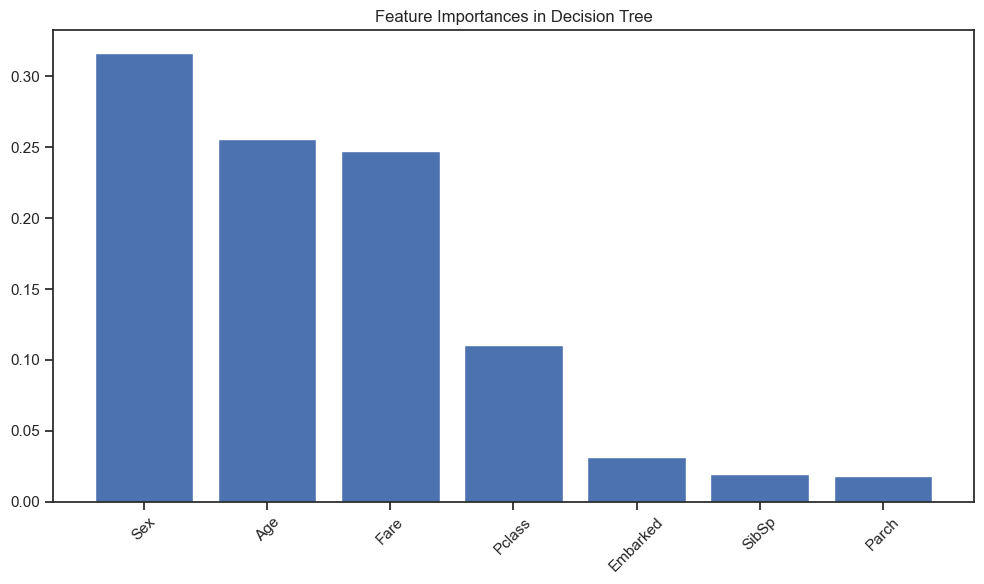

Decision Tree (max_depth=3) | Accuracy: 0.7933 | F1-Score: 0.6726


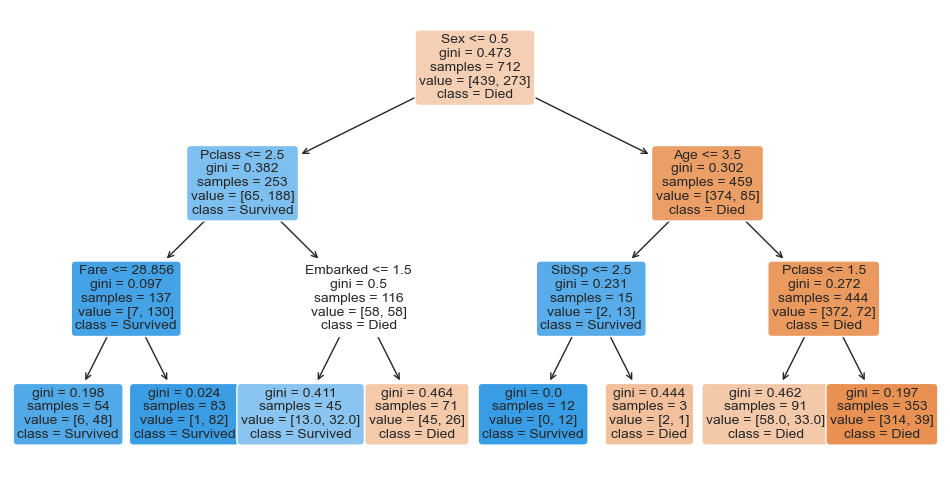

In [96]:
import matplotlib.pyplot as plt

# График важности
importances = tree.feature_importances_
indices = importances.argsort()[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances in Decision Tree")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [X.columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

from sklearn.tree import DecisionTreeClassifier, plot_tree

# Ограничиваем глубину дерева (например, 3 уровня)
# Это сделает дерево меньше, понятнее и ускорит обучение
tree = DecisionTreeClassifier(random_state=42, max_depth=3).fit(X_train, y_train)

# Оцениваем качество
preds = tree.predict(X_test)
acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds)
print(f"Decision Tree (max_depth=3) | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

# Визуализация (размер фигуры уменьшен, так как дерево маленькое)
plt.figure(figsize=(12, 6))
plot_tree(tree, 
          feature_names=X.columns, 
          class_names=['Died', 'Survived'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()